# Z-Score Strategy

The Z-Score strategy is described in *Algorithmic Trading* by *Ernest P. Chan*. The strategy uses the Z-Score computed from a moving average and moving standard deviation with window equal to the half-life of mean reversion, namely,

$
\begin{align}
Z = \frac{y - \text{moving\_avg}(y, \text{halflife})}{\text{moving\_std}(y, \text{halflife})}
\end{align}
\tag{1}
$

The strategy involves holding a position equal to a multiple of the negative of the Z-Score. If it is negative a long position is held. For this case the the current price is below the mean value. If it is positive two options are available and investigated. In the first no position is held and in the second a short position is held that is a multiple of the Z-Score. For this case the price is above the mean.</br>

The aim of the strategy is to reduce the risk of holding a relatively large position when the mean reverts. The strategy holds a larger long or short position the further the current price is from the mean value and as the price approaches the mean the position is reduced.</br>

The asset analyzed is the USD/CAD exchange rate, CAD=X.

## Strategy Exit Position on Positive Z-Score

This version of the strategy holds a long position for negative z-score and nothing for a positive z-score.

In [15]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
import numpy
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
import lib.plots.dash.backtrader as dash
from lib.plots import (curve, bar, twinx_bar_line, fcurve_scatter_comparison, positive_negative_bar, 
                       zscore_backtest)
from lib.data import stats
from lib.data.backtrader import compute_mean_reversion_halflife
from lib.db import BacktestDb

# Config Plot Style
pyplot.style.use(config.glyfish_style)

In [3]:
def zscore_plot(zscore, zdate, window):
    window=int(window)
    title = f'USD.CAD Exchange Calculated Rate Z-Score: $t_{{1/2}} = {window:.0f}$ days'
    curve(zscore[window:], zdate[window:], title=title, xlabel=f"Day", ylabel="Z-Score", lw=1)

db = BacktestDb()
backtest_id = '7egA5yNfkN7t'
file_root = '../../../data/algorithmic_trading'

In [3]:
# db.insert_yahoo_price_series("CAD=X", file_root)

## Asset CAD=X

In [4]:
price_series_data = db.fetch_price_series("CAD=X", start_date='2007-07-22', end_date='2012-03-28')
price_series_data.head()

,ticker,date,open_price,high_price,low_price,close_price,adj_close_price,volume
0,CAD=X,2007-07-23,1.0479,1.04790,1.0424,1.04676,1.04676,0.0
1,CAD=X,2007-07-24,1.0466,1.04726,1.0340,1.03660,1.03660,0.0
2,CAD=X,2007-07-25,1.0366,1.04455,1.0342,1.04180,1.04180,0.0
3,CAD=X,2007-07-26,1.0418,1.05680,1.0403,1.05360,1.05360,0.0
4,CAD=X,2007-07-27,1.0536,1.06530,1.0501,1.06390,1.06390,0.0


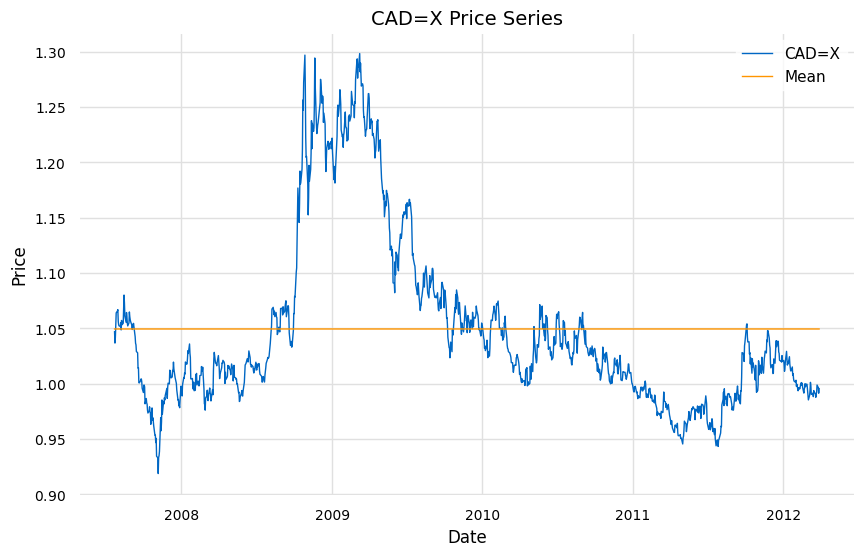

In [5]:
dash.price_series(price_series_data)

### Mean Reversion Halflife

In [6]:
mean_reversion_half_life, result, _ = compute_mean_reversion_halflife(price_series_data.close_price.to_numpy())
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     3.294
Date:                Sat, 25 May 2024   Prob (F-statistic):             0.0698
Time:                        18:42:26   Log-Likelihood:                 4061.0
No. Observations:                1215   AIC:                            -8118.
Df Residuals:                    1213   BIC:                            -8108.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -4.194e-05      0.000     -0.171      0.864      -0.001       0.000
x1            -0.0056      0.003     -1.815      0.070      -0.012       0.000
==============================================================================
Omnibus:                      113.526   Durbin-Watson:                   1.979
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              434.957
Skew:                           0.380   Prob(JB):                     3.55e-95
Kurtosis:                       5.831   Cond. No.                         12.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [7]:
mean_reversion_half_life

123.81305867441176

### Z-Score Indicator

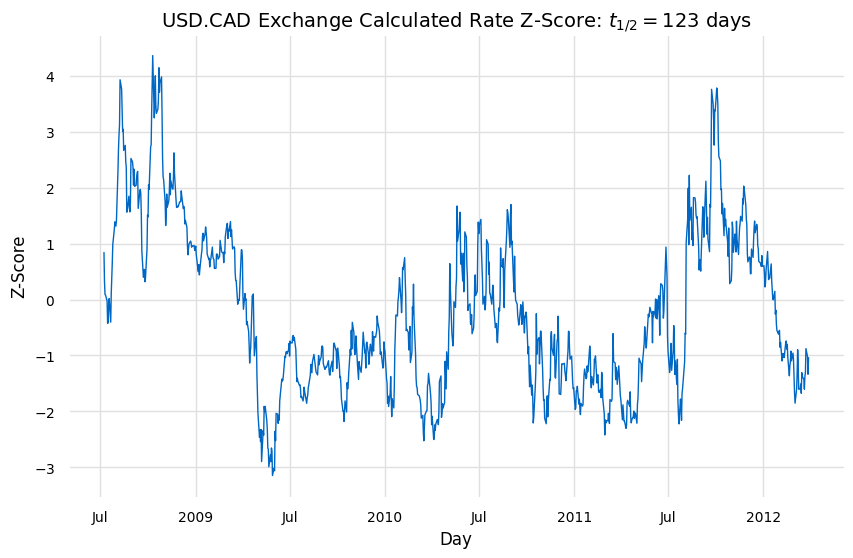

In [8]:
zdate, zscore = stats.compute_zscore(price_series_data.date.to_numpy(), price_series_data.close_price.to_numpy(), int(mean_reversion_half_life))
zscore_plot(zscore, zdate, mean_reversion_half_life)

In [9]:
asset_price_data = db.fetch_asset_price(backtest_id)
asset_price_data.head()

,date,run_id,ticker,ensemble_id,open_price,high_price,low_price,close_price
0,2008-01-15,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,1.02,1.02,1.01,1.02
1,2008-01-16,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,1.02,1.03,1.02,1.02
2,2008-01-17,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,1.02,1.03,1.02,1.03
3,2008-01-18,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,1.03,1.03,1.02,1.03
4,2008-01-21,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,1.03,1.04,1.03,1.04


### Asset Price

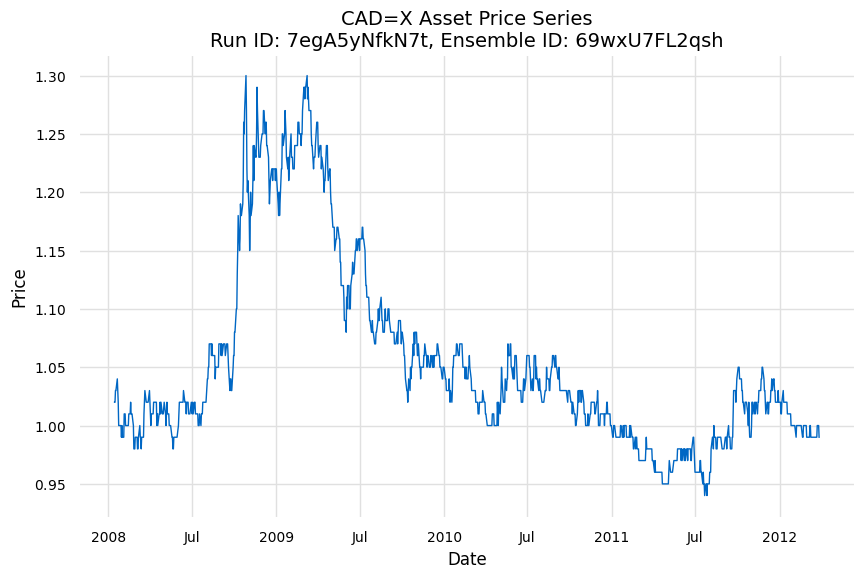

In [10]:
dash.asset_price(asset_price_data)

### Balance

In [11]:
broker_data = db.fetch_broker(backtest_id)
broker_data.head()

,date,run_id,ensemble_id,cash,value
0,2008-01-15,7egA5yNfkN7t,69wxU7FL2qsh,1000.0,1000.0
1,2008-01-16,7egA5yNfkN7t,69wxU7FL2qsh,1000.0,1000.0
2,2008-01-17,7egA5yNfkN7t,69wxU7FL2qsh,1000.0,1000.0
3,2008-01-18,7egA5yNfkN7t,69wxU7FL2qsh,1000.0,1000.0
4,2008-01-21,7egA5yNfkN7t,69wxU7FL2qsh,1000.0,1000.0


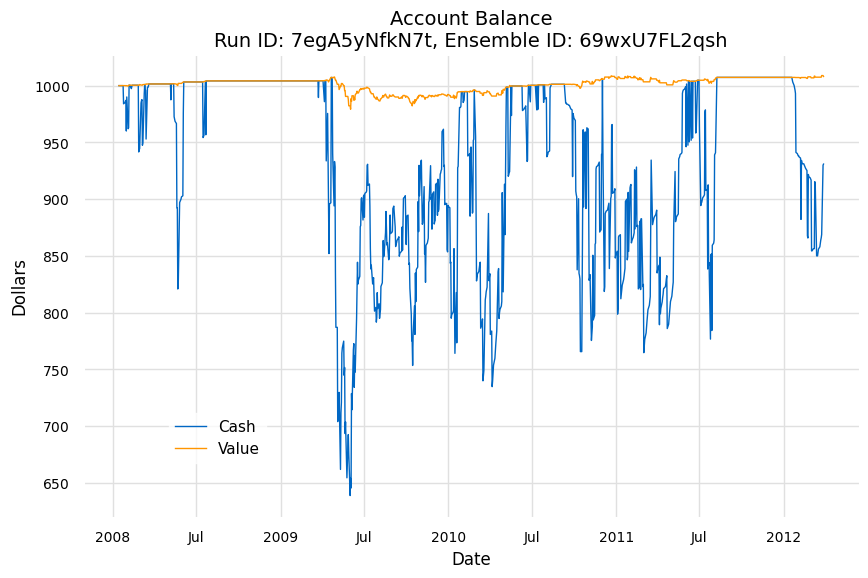

In [12]:
dash.cash_value(broker_data)

### Position

In [13]:
position_data = db.fetch_position(backtest_id)
position_data.tail()

,date,run_id,ticker,ensemble_id,adjbase,price,price_orig,size,upclosed,upopened,updt
610,2012-03-21,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,0.99,0.992172,0.992172,145,-3.0,0.0,None
611,2012-03-22,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,0.99,0.992172,0.992172,143,-2.0,0.0,None
612,2012-03-23,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,1.00,0.992172,0.992172,140,-3.0,0.0,None
613,2012-03-26,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,1.00,0.992172,0.992172,79,-61.0,0.0,None
614,2012-03-27,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,0.99,0.992172,0.992172,78,-1.0,0.0,None


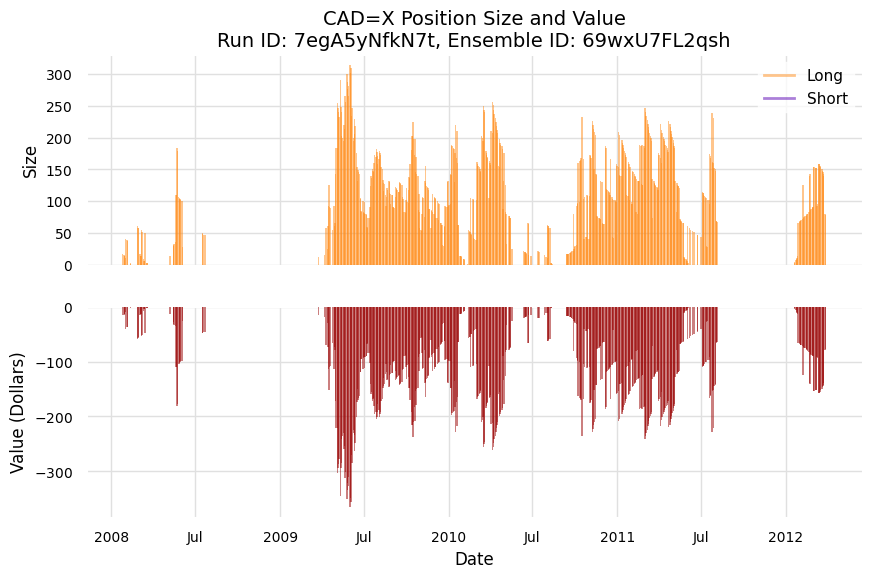

In [14]:
dash.position(position_data)

### Z-Score Indicator

In [15]:
zscore_data = db.fetch_zscore_indicator(backtest_id)
zscore_data.head()

,date,run_id,indicator,ensemble_id,ticker,zscore,half_life,stake_multiple
0,2008-01-15,7egA5yNfkN7t,zscore,69wxU7FL2qsh,CAD=X,0.328399,124,100
1,2008-01-16,7egA5yNfkN7t,zscore,69wxU7FL2qsh,CAD=X,0.336484,124,100
2,2008-01-17,7egA5yNfkN7t,zscore,69wxU7FL2qsh,CAD=X,0.608822,124,100
3,2008-01-18,7egA5yNfkN7t,zscore,69wxU7FL2qsh,CAD=X,0.611988,124,100
4,2008-01-21,7egA5yNfkN7t,zscore,69wxU7FL2qsh,CAD=X,0.886193,124,100


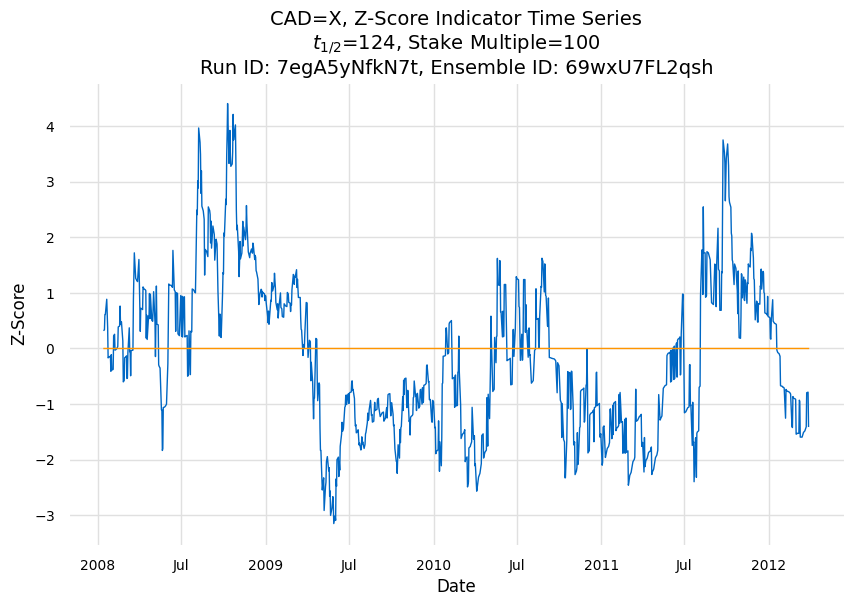

In [16]:
dash.zscore_indicator(zscore_data)

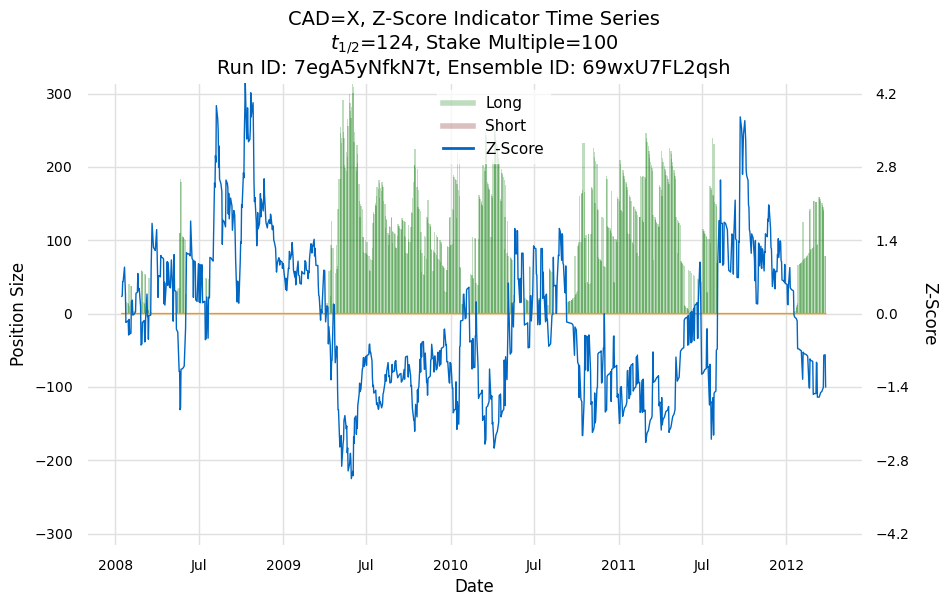

In [17]:
dash.zscore_indicator_position(zscore_data, position_data)

### Trades

In [18]:
asset_price_data = db.fetch_asset_price(backtest_id)
asset_price_data.head()

,date,run_id,ticker,ensemble_id,open_price,high_price,low_price,close_price
0,2008-01-15,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,1.02,1.02,1.01,1.02
1,2008-01-16,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,1.02,1.03,1.02,1.02
2,2008-01-17,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,1.02,1.03,1.02,1.03
3,2008-01-18,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,1.03,1.03,1.02,1.03
4,2008-01-21,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,1.03,1.04,1.03,1.04


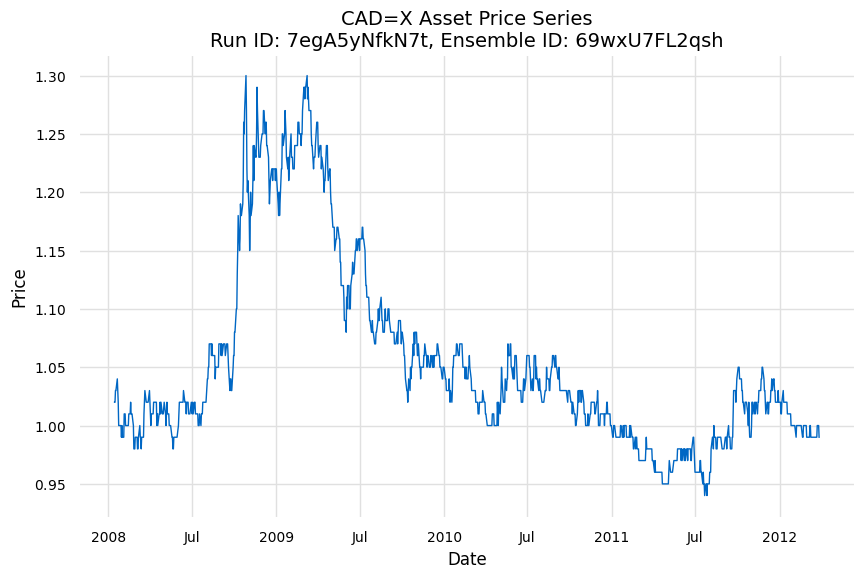

In [19]:
dash.asset_price(asset_price_data)

In [20]:
trades_data = db.fetch_trades(backtest_id)
trades_data.head()

,date,run_id,ticker,ensemble_id,status,trade_id,size,price,value,commission,pnl,pnlcomm,dtclose,dtopen,baropen,barclose,barlen,is_long
0,2008-01-25,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,Open,2256997278,16,1.00,16.0,0.0,0.00,0.00,None,2008-01-25,132,0,0,True
1,2008-02-06,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,Closed,2256997278,0,1.00,0.0,0.0,0.37,0.37,2008-02-06,2008-01-25,132,140,8,True
2,2008-02-11,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,Open,1030077772,3,1.00,3.0,0.0,0.00,0.00,None,2008-02-11,143,0,0,True
3,2008-02-13,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,Closed,1030077772,0,1.00,0.0,0.0,0.00,0.00,2008-02-13,2008-02-11,143,145,2,True
4,2008-02-27,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,Open,3241144325,60,0.98,58.8,0.0,0.00,0.00,None,2008-02-27,155,0,0,True


In [21]:
open_trades = trades_data.query('status == "Open"')
open_trades.head()

,date,run_id,ticker,ensemble_id,status,trade_id,size,price,value,commission,pnl,pnlcomm,dtclose,dtopen,baropen,barclose,barlen,is_long
0,2008-01-25,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,Open,2256997278,16,1.00,16.00,0.0,0.0,0.0,None,2008-01-25,132,0,0,True
2,2008-02-11,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,Open,1030077772,3,1.00,3.00,0.0,0.0,0.0,None,2008-02-11,143,0,0,True
4,2008-02-27,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,Open,3241144325,60,0.98,58.80,0.0,0.0,0.0,None,2008-02-27,155,0,0,True
6,2008-03-12,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,Open,1109886000,5,0.99,4.95,0.0,0.0,0.0,None,2008-03-12,165,0,0,True
8,2008-05-07,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,Open,1809801740,14,1.00,14.00,0.0,0.0,0.0,None,2008-05-07,203,0,0,True


In [22]:
closed_trades = trades_data.query('status == "Closed"')
closed_trades.head()

,date,run_id,ticker,ensemble_id,status,trade_id,size,price,value,commission,pnl,pnlcomm,dtclose,dtopen,baropen,barclose,barlen,is_long
1,2008-02-06,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,Closed,2256997278,0,1.00000,0.0,0.0,0.37,0.37,2008-02-06,2008-01-25,132,140,8,True
3,2008-02-13,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,Closed,1030077772,0,1.00000,0.0,0.0,0.00,0.00,2008-02-13,2008-02-11,143,145,2,True
5,2008-03-11,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,Closed,3241144325,0,0.98000,0.0,0.0,0.63,0.63,2008-03-11,2008-02-27,155,164,9,True
7,2008-03-20,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,Closed,1109886000,0,0.98102,0.0,0.0,0.48,0.48,2008-03-20,2008-03-12,165,171,6,True
9,2008-05-08,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,Closed,1809801740,0,1.00000,0.0,0.0,0.14,0.14,2008-05-08,2008-05-07,203,204,1,True


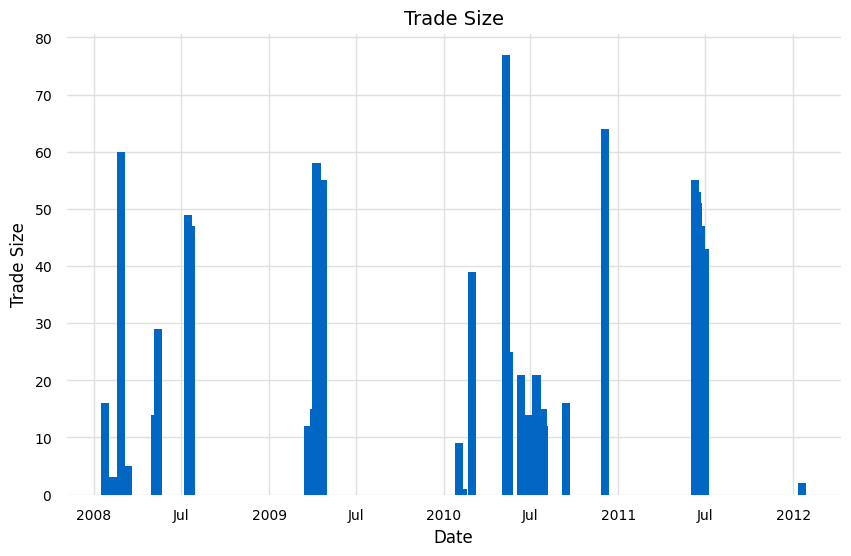

In [23]:
bar(open_trades['size'].to_numpy(), open_trades.date.to_numpy(), title='Trade Size', ylabel='Trade Size', alpha=1.0, xlabel='Date')

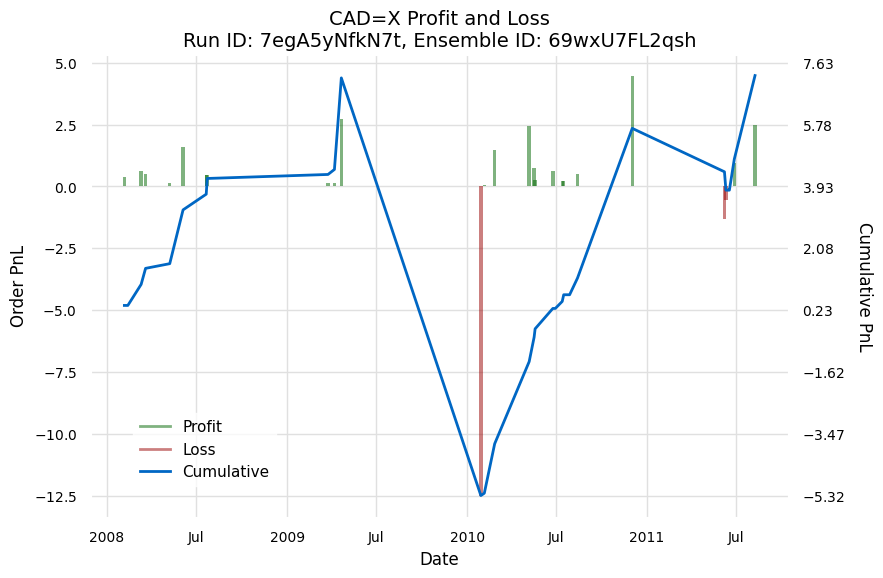

In [24]:
dash.pnl(closed_trades)

### Orders

In [4]:
orders_data = db.fetch_orders(backtest_id)
orders_data.head()

,date,run_id,ticker,ensemble_id,order_status,order_type,trade_id,price,value,size,commission,pnl,exec_type
0,2008-01-25,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,Submitted,Buy,2256997278,1.0,0.0,16,0.0,0.0,Market
1,2008-01-25,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,Accepted,Buy,2256997278,1.0,0.0,16,0.0,0.0,Market
2,2008-01-25,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,Completed,Buy,2256997278,1.0,16.0,16,0.0,0.0,Market
3,2008-01-28,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,Submitted,Sell,2256997278,1.0,0.0,-1,0.0,0.0,Market
4,2008-01-28,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,Accepted,Sell,2256997278,1.0,0.0,-1,0.0,0.0,Market


In [9]:
completed_orders = orders_data.query('order_status == "Completed"')
completed_orders.head()

,date,run_id,ticker,ensemble_id,order_status,order_type,trade_id,price,value,size,commission,pnl,exec_type
2,2008-01-25,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,Completed,Buy,2256997278,1.00,16.0,16,0.0,0.00,Market
5,2008-01-28,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,Completed,Sell,2256997278,1.01,1.0,-1,0.0,0.01,Market
8,2008-01-29,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,Completed,Sell,2256997278,1.00,1.0,-1,0.0,0.00,Market
11,2008-01-30,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,Completed,Sell,2256997278,1.00,1.0,-1,0.0,0.00,Market
14,2008-01-31,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,Completed,Buy,2256997278,1.00,27.0,27,0.0,0.00,Market


In [10]:
buy_orders = completed_orders.query('order_type == "Buy" and order_status == "Completed"')
buy_orders.head(10)

,date,run_id,ticker,ensemble_id,order_status,order_type,trade_id,price,value,size,commission,pnl,exec_type
2,2008-01-25,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,Completed,Buy,2256997278,1.00,16.00,16,0.0,0.0,Market
14,2008-01-31,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,Completed,Buy,2256997278,1.00,27.00,27,0.0,0.0,Market
20,2008-02-04,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,Completed,Buy,2256997278,1.00,28.00,28,0.0,0.0,Market
29,2008-02-11,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,Completed,Buy,1030077772,1.00,3.00,3,0.0,0.0,Market
38,2008-02-27,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,Completed,Buy,3241144325,0.98,58.80,60,0.0,0.0,Market
56,2008-03-06,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,Completed,Buy,3241144325,0.98,40.18,41,0.0,0.0,Market
68,2008-03-12,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,Completed,Buy,1109886000,0.99,4.95,5,0.0,0.0,Market
71,2008-03-14,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,Completed,Buy,1109886000,0.98,43.12,44,0.0,0.0,Market
83,2008-05-07,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,Completed,Buy,1809801740,1.00,14.00,14,0.0,0.0,Market
89,2008-05-14,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,Completed,Buy,3043819512,1.00,29.00,29,0.0,0.0,Market


In [12]:
sell_orders = orders_data.query('order_type == "Sell" and order_status == "Completed"')
sell_orders.head(20)

,date,run_id,ticker,ensemble_id,order_status,order_type,trade_id,price,value,size,commission,pnl,exec_type
5,2008-01-28,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,Completed,Sell,2256997278,1.01,1.000000,-1,0.0,0.010000,Market
8,2008-01-29,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,Completed,Sell,2256997278,1.00,1.000000,-1,0.0,0.000000,Market
11,2008-01-30,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,Completed,Sell,2256997278,1.00,1.000000,-1,0.0,0.000000,Market
17,2008-02-01,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,Completed,Sell,2256997278,1.00,30.000000,-30,0.0,0.000000,Market
23,2008-02-05,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,Completed,Sell,2256997278,0.99,1.000000,-1,0.0,-0.010000,Market
26,2008-02-06,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,Completed,Sell,2256997278,1.01,37.000000,-37,0.0,0.370000,Market
32,2008-02-12,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,Completed,Sell,1030077772,1.00,2.000000,-2,0.0,0.000000,Market
35,2008-02-13,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,Completed,Sell,1030077772,1.00,1.000000,-1,0.0,0.000000,Market
41,2008-02-28,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,Completed,Sell,3241144325,0.98,1.960000,-2,0.0,0.000000,Market
44,2008-02-29,7egA5yNfkN7t,CAD=X,69wxU7FL2qsh,Completed,Sell,3241144325,0.98,0.980000,-1,0.0,0.000000,Market


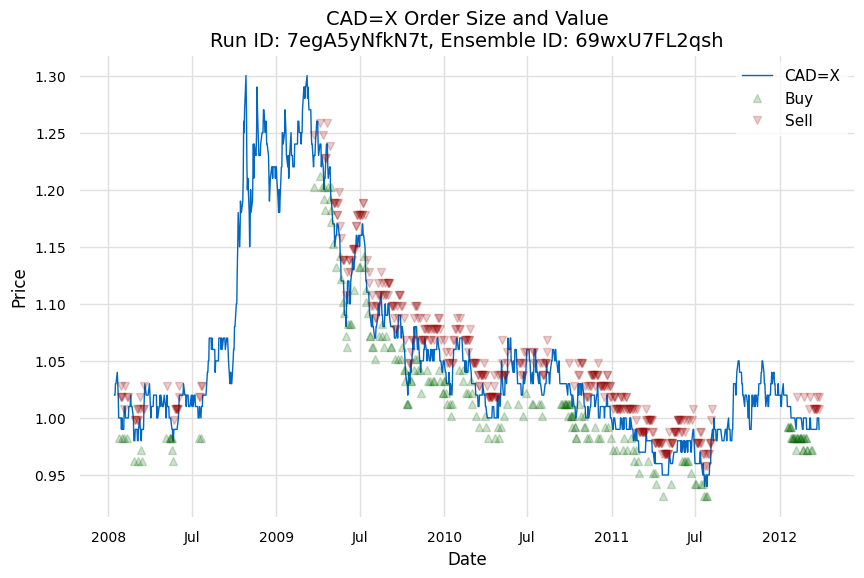

In [29]:
dash.orders(orders_data, asset_price_data)

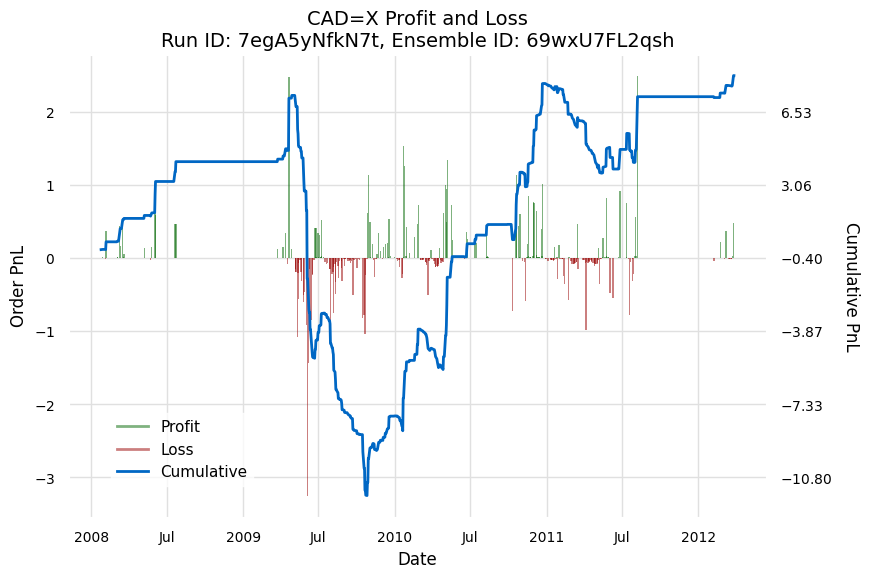

In [30]:
dash.order_pnl(orders_data)

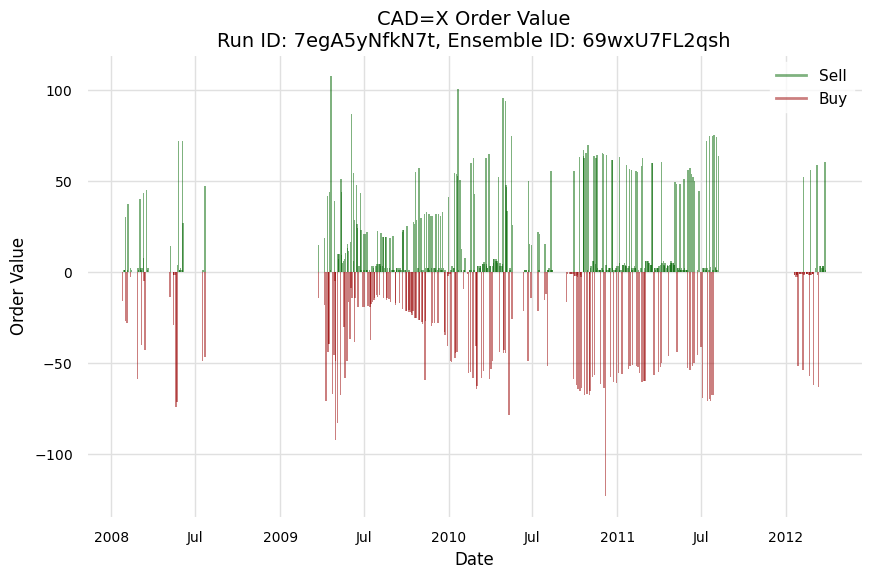

In [31]:
dash.order_value(orders_data)

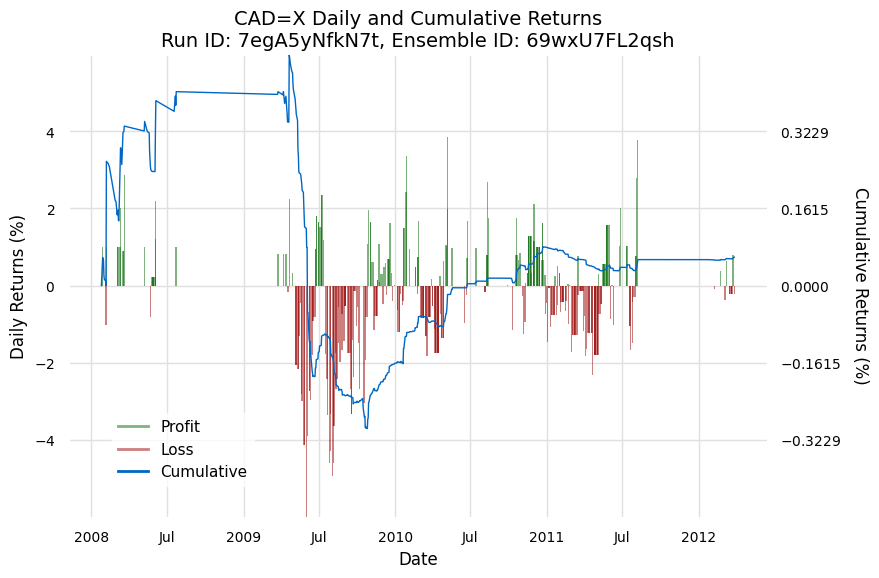

In [16]:
dash.returns(orders_data)

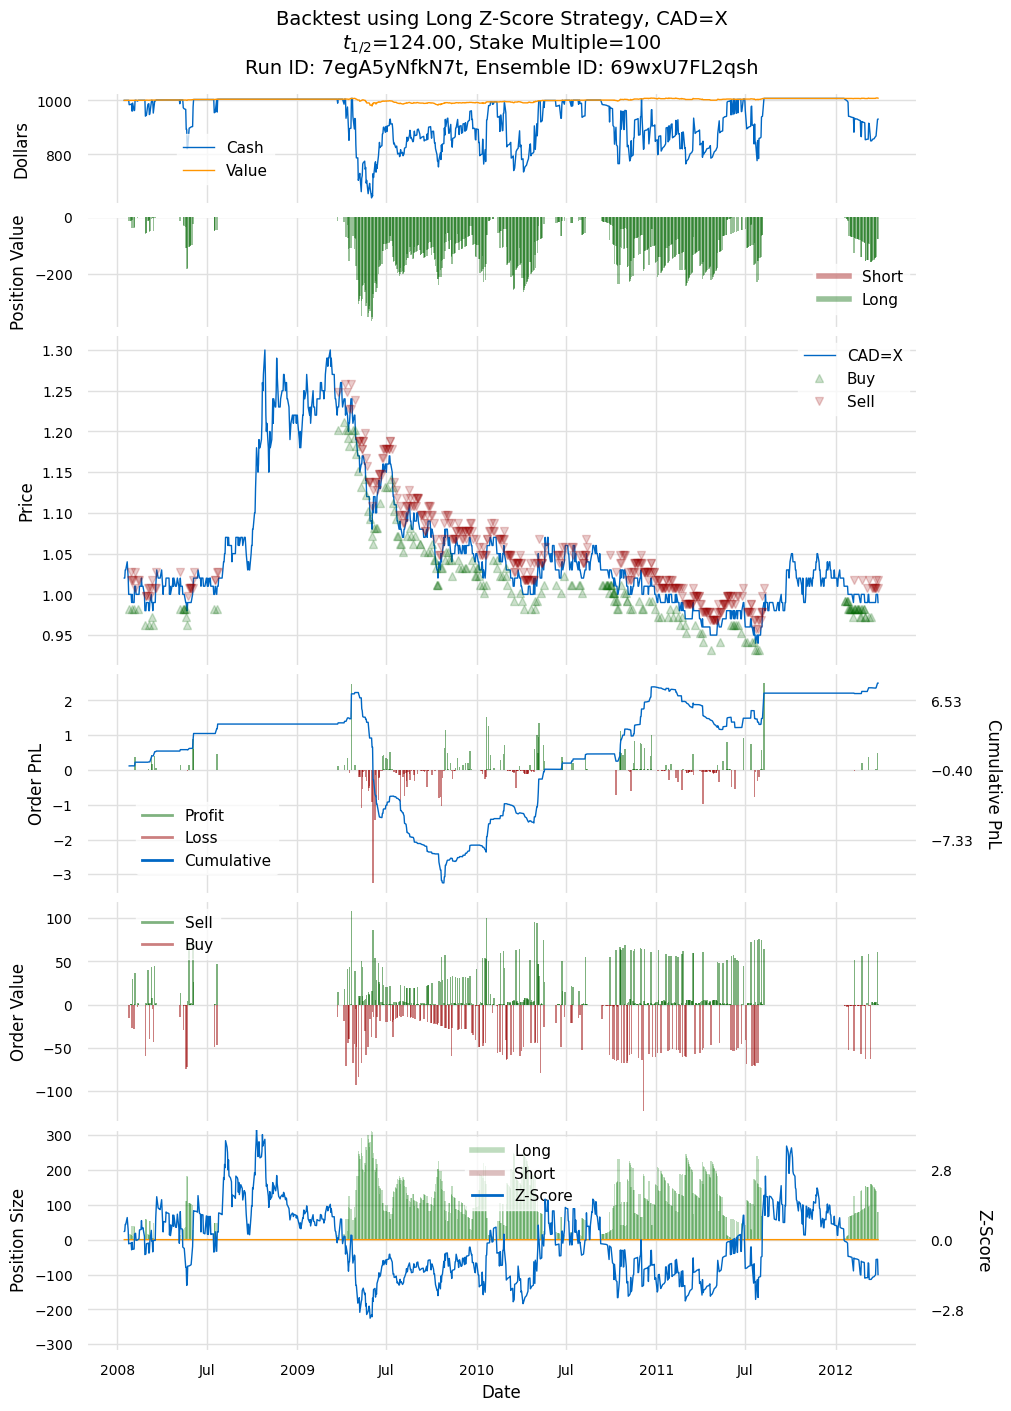

In [32]:
zscore_backtest(broker=broker_data, zscore_indicator=zscore_data, asset=asset_price_data, position=position_data, 
                orders=orders_data, strategy="Backtest using Long Z-Score Strategy") 